# Using RaCo Keypoints for Matching with LightGlue

In this example we show how you can use RaCo's keypoints with descriptors from ALIKED with LightGlue for matching.

In [ ]:
import torch
from lightglue import ALIKED, LightGlue

from raco import RaCo
from raco.utils import load_image, rbd

device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize the models
extractor = RaCo(max_num_keypoints=5000).eval().to(device)
descriptor = ALIKED().eval().to(device)
matcher = LightGlue(features="raco-aliked").eval().to(device)

[RaCo] Loaded weights from https://github.com/cvg/RaCo/releases/download/v1.0.0/raco.pth


In [20]:
image0 = load_image(
    "assets/DJI_20250409111225_0125_V.jpg", resize=1280
).to(device)
image1 = load_image(
    "assets/DJI_20250409111503_0198_V.jpg", resize=1280
).to(device)

with torch.inference_mode():
    feats0 = extractor.extract(image0)
    feats0["descriptors"] = descriptor.describe(feats0["keypoints"], image0)

    feats1 = extractor.extract(image1)
    feats1["descriptors"] = descriptor.describe(feats1["keypoints"], image1)

    matches01 = matcher({"image0": feats0, "image1": feats1})

feats0, feats1, matches01 = [
    rbd(x) for x in [feats0, feats1, matches01]
]  # remove batch dimension

# Extract matches
kpts0, kpts1, matches = feats0["keypoints"], feats1["keypoints"], matches01["matches"]
m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]]

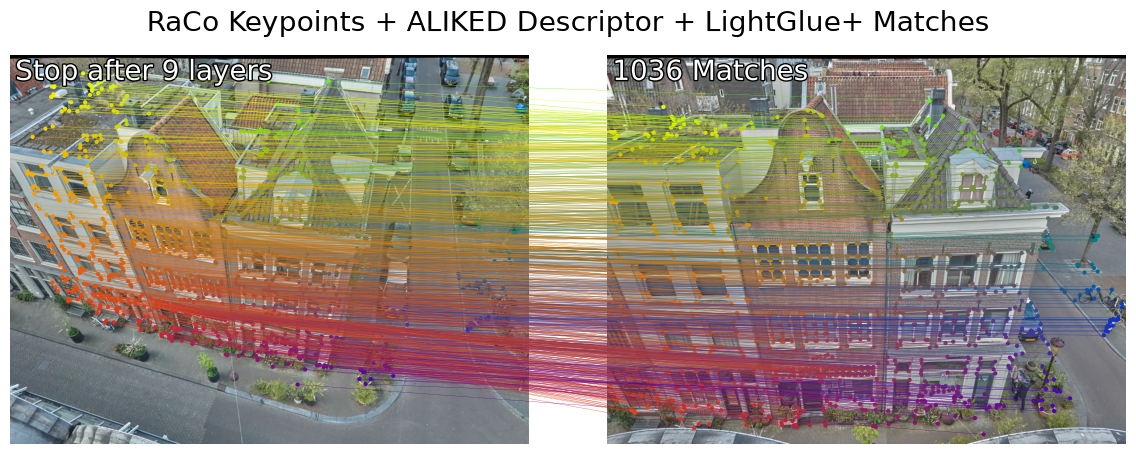

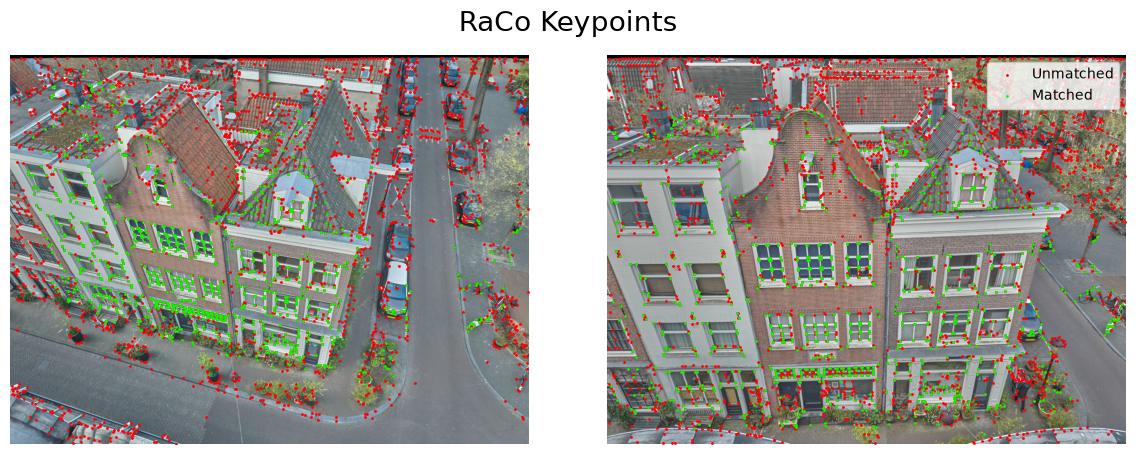

In [21]:
import matplotlib.pyplot as plt
from lightglue import viz2d

viz2d.plot_images([image0, image1])
viz2d.plot_matches(m_kpts0, m_kpts1, color=None, lw=0.2)
viz2d.add_text(0, f"Stop after {matches01['stop']} layers", fs=20)
viz2d.add_text(1, f"{len(m_kpts0)} Matches", fs=20)
plt.gcf().subplots_adjust(top=0.88)
plt.suptitle("RaCo Keypoints + ALIKED Descriptor + LightGlue+ Matches", fontsize=20)

viz2d.plot_images([image0, image1])
viz2d.plot_keypoints([kpts0, kpts1], colors="red")
viz2d.plot_keypoints([m_kpts0, m_kpts1], colors="lime")
plt.legend(["Unmatched", "Matched"], loc="upper right")
plt.gcf().subplots_adjust(top=0.88)
plt.suptitle("RaCo Keypoints", fontsize=20)
plt.show()

## Baseline: ALIKED + LightGlue (without RaCo)

For a direct comparison, this baseline uses ALIKED for both keypoint detection and description, followed by the standard ALIKED-trained LightGlue matcher. It uses the same images, resize, device, and maximum number of keypoints as the RaCo pipeline above.

In [ ]:
# Initialize the baseline models. The LightGlue weights are downloaded on first use.
aliked_extractor = ALIKED(max_num_keypoints=5000).eval().to(device)
aliked_matcher = LightGlue(features="aliked").eval().to(device)

with torch.inference_mode():
    aliked_feats0 = aliked_extractor.extract(image0)
    aliked_feats1 = aliked_extractor.extract(image1)
    aliked_matches01 = aliked_matcher(
        {"image0": aliked_feats0, "image1": aliked_feats1}
    )

aliked_feats0, aliked_feats1, aliked_matches01 = [
    rbd(x) for x in [aliked_feats0, aliked_feats1, aliked_matches01]
]

aliked_kpts0 = aliked_feats0["keypoints"]
aliked_kpts1 = aliked_feats1["keypoints"]
aliked_matches = aliked_matches01["matches"]
aliked_m_kpts0 = aliked_kpts0[aliked_matches[..., 0]]
aliked_m_kpts1 = aliked_kpts1[aliked_matches[..., 1]]

print(f"RaCo + ALIKED descriptor: {len(m_kpts0)} matches")
print(f"ALIKED detector + descriptor: {len(aliked_m_kpts0)} matches")

2.2%

Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/aliked_lightglue.pth" to /Users/elsagong/.cache/torch/hub/checkpoints/aliked_lightglue_v0-1_arxiv.pth


100.0%


RaCo + ALIKED descriptor: 1036 matches
ALIKED detector + descriptor: 962 matches


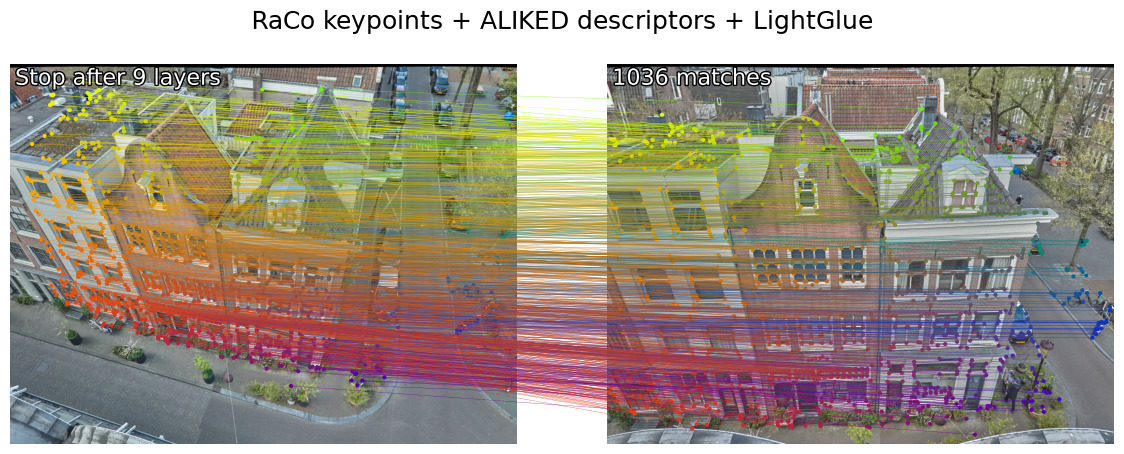

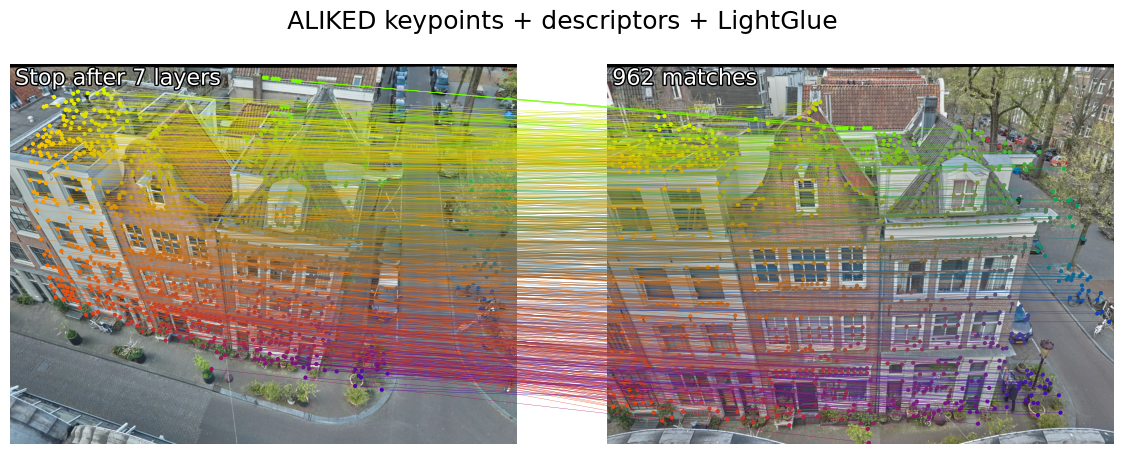

In [23]:
# Plot both methods with identical visualization settings.
for title, matched0, matched1, result in [
    (
        "RaCo keypoints + ALIKED descriptors + LightGlue",
        m_kpts0,
        m_kpts1,
        matches01,
    ),
    (
        "ALIKED keypoints + descriptors + LightGlue",
        aliked_m_kpts0,
        aliked_m_kpts1,
        aliked_matches01,
    ),
]:
    viz2d.plot_images([image0, image1])
    viz2d.plot_matches(matched0, matched1, color=None, lw=0.2)
    viz2d.add_text(0, f"Stop after {result['stop']} layers", fs=16)
    viz2d.add_text(1, f"{len(matched0)} matches", fs=16)
    plt.gcf().subplots_adjust(top=0.86)
    plt.suptitle(title, fontsize=18)

plt.show()